In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from numba import jit
import scipy
import pandas as pd

In [3]:
from integrator import run

In [5]:
run.run_system(config_path='/Users/emadonev/Documents/PROJECTS/nbody_exoplanets/systems/configs/GJ667__default__Ce0.0__Ci0.json')

'/Users/emadonev/Documents/PROJECTS/nbody_exoplanets/output/GJ667__default__Ce0.0__Ci0.h5'

In [4]:
run.run_system(config_path='/Users/emadonev/Documents/PROJECTS/nbody_exoplanets/systems/configs/LTT1445__three_planet.json')

'/Users/emadonev/Documents/PROJECTS/nbody_exoplanets/output/LTT1445__three_planet.h5'

In [10]:
#H5_PATH = '/Users/emadonev/Documents/PROJECTS/nbody_exoplanets/output/GJ667__default__Ce0.0__Ci0.h5'
H5_PATH = '/Users/emadonev/Documents/PROJECTS/nbody_exoplanets/output/LTT1445__three_planet.h5'

In [11]:
with h5py.File(H5_PATH, "r") as f:
        keys = sorted(
            [k for k in f.keys() if k.startswith("Step_")],
            key=lambda s: int(s.split("_")[1])
        )
        
        t_list, pos_list, vel_list, mass_list, ptype_list = [], [], [], [], []

        for k in keys:
                    g = f[k]
                    t_list.append(g["time"][:])
                    pos_list.append(g["pos"][:])
                    vel_list.append(g['vel'][:])
                    mass_list.append(g["mass"][:])
                    ptype_list.append(g["ptype"][:])
        
        t = np.concatenate(t_list)
        pos = np.concatenate(pos_list)
        vel = np.concatenate(vel_list)
        mass = np.concatenate(mass_list)
        ptype = np.concatenate(ptype_list)

        n_particles = mass.shape[1]


In [12]:
from integrator.physics import Physics
from integrator import constants

In [13]:
n_snap = pos.shape[0]
phys = Physics()
pos = pos.reshape(n_snap, n_particles, 3)
vel = vel.reshape(n_snap, n_particles, 3)     

# energy at each snapshot (masses are constant in time, so mass[s] == mass[0])
E = np.array([phys.energy(pos[s], vel[s], mass[s], constants.G)
              for s in range(n_snap)])

rel_err = np.abs((E - E[0]) / E[0])            # dimensionless
print("max |dE/E| :", rel_err.max())
print("final |dE/E|:", rel_err[-1])

max |dE/E| : 0.002646019401073151
final |dE/E|: 0.0026440748430950965


Text(0, 0.5, '|dE/E|')

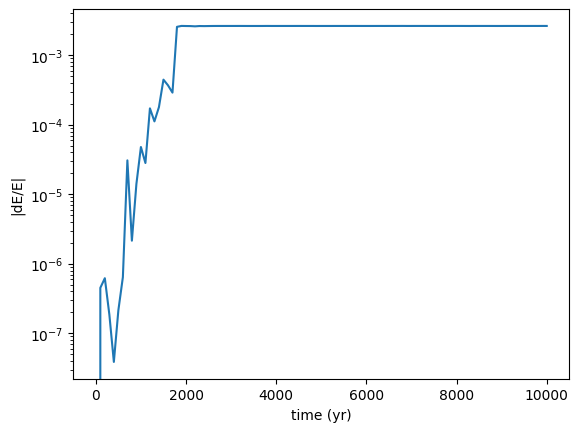

In [14]:
import matplotlib.pyplot as plt
plt.plot(t, rel_err); plt.yscale('log'); plt.xlabel('time (yr)'); plt.ylabel('|dE/E|')

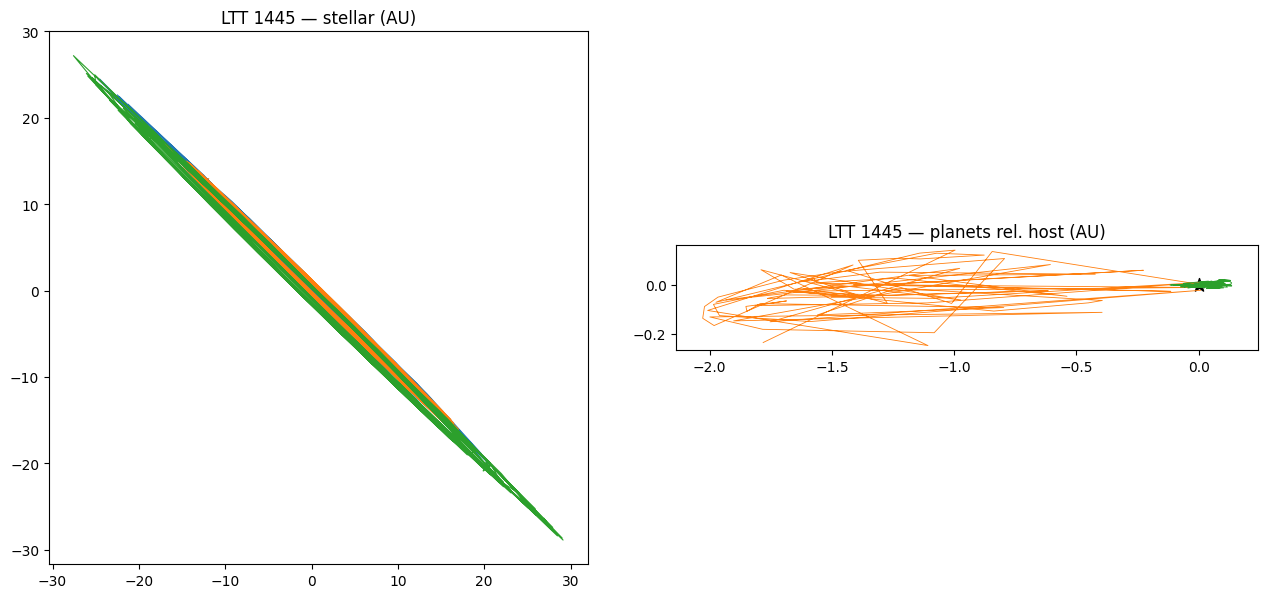

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_system(pos, ptype, title):
    pt = ptype[0] if ptype.ndim == 2 else ptype     # types are constant in time
    stars   = np.where(pt == 0)[0]
    planets = np.where(pt == 1)[0]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

    # absolute (barycentric) — the wide stellar orbits
    for s in stars:
        ax1.plot(pos[:, s, 0], pos[:, s, 1], lw=0.8)
        ax1.scatter(pos[0, s, 0], pos[0, s, 1], s=60, marker='*')
    ax1.set_title(f'{title} — stellar (AU)'); ax1.set_aspect('equal')

    # relative to host (nearest star) — the tight planet orbits
    for p in planets:
        d = [np.linalg.norm(pos[:, p] - pos[:, s], axis=1).mean() for s in stars]
        host = stars[int(np.argmin(d))]
        rel = pos[:, p] - pos[:, host]
        ax2.plot(rel[:, 0], rel[:, 1], lw=0.6)
    ax2.scatter(0, 0, s=100, marker='*', color='k')
    ax2.set_title(f'{title} — planets rel. host (AU)'); ax2.set_aspect('equal')

    plt.tight_layout(); plt.show()

plot_system(pos, ptype, 'LTT 1445')     # and again for LTT 1445